# H1 클러스터링 실험: 파킹 유저 분리

**목표:** K-Means + DBSCAN으로 파킹 유저 클러스터 분리 가능성 검증 (H1)

**피처 세트 (Feature Set A — raw):**
`avg_monthly_delta_level`, `delta_cp` (winsorized P5–P95), `delta_union` (clamped ≥ 0), `avg_monthly_delta_authentic_symbol`, `arcane_stagnant`

**데이터:** `data/features_monthly.csv` → level ≥ 260 필터 후 ~1,380명
(eda.ipynb Sec 0–10 전처리 자체 재현 — eda.ipynb 수정 없음)


In [1]:
import os
os.makedirs("figures", exist_ok=True)

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager
_font_path = '../assets/NanumSquareNeo-bRg.ttf'
font_manager.fontManager.addfont(_font_path)
_font_prop = font_manager.FontProperties(fname=_font_path)
matplotlib.rcParams['font.family'] = _font_prop.get_name()
matplotlib.rcParams['axes.unicode_minus'] = False
import seaborn as sns
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# --- 데이터 로드 ---
df_raw = pd.read_csv('../data/features_monthly.csv', encoding='utf-8-sig')

# Sec 1 재현: listwise deletion (key delta columns)
DELTA_COLS = ['avg_monthly_delta_level', 'avg_monthly_delta_combat_power',
              'avg_monthly_delta_union_level']
df_clean = df_raw.dropna(subset=DELTA_COLS).copy()

# Sec 10 재현: 전처리
df_clean['delta_cp'] = np.array(
    winsorize(df_clean['avg_monthly_delta_combat_power'], limits=[0.05, 0.05])
)
df_clean['delta_union'] = df_clean['avg_monthly_delta_union_level'].clip(lower=0)
df_clean['delta_arcane'] = (
    df_clean['avg_monthly_delta_arcane_symbol'].fillna(0).clip(lower=0)
)
df_clean['arcane_score'] = df_clean['arcane_symbol_score'].fillna(0)
df_clean['arcane_stagnant'] = (
    (df_clean['arcane_score'] < 120) & (df_clean['delta_arcane'] == 0)
).astype(int)

# level >= 260 필터
df_final = df_clean[df_clean['level'] >= 260].copy().reset_index(drop=True)

# level band
LEVEL_BANDS = [260, 270, 280, 290, 300, 301]
BAND_LABELS = ['260s', '270s', '280s', '290s', '300']
df_final['level_band'] = pd.cut(
    df_final['level'], bins=LEVEL_BANDS, labels=BAND_LABELS, right=False
)

# stagnation_score: 각 피처 P25 이하 = 1점씩 (arcane_stagnant 포함)
stag_features = ['avg_monthly_delta_level', 'delta_cp', 'delta_union',
                 'avg_monthly_delta_authentic_symbol']
df_final['stagnation_score'] = (
    sum((df_final[c] <= df_final[c].quantile(0.25)).astype(int)
        for c in stag_features)
    + df_final['arcane_stagnant']
)

CLUSTER_FEATURES = [
    'avg_monthly_delta_level',
    'delta_cp',
    'delta_union',
    'avg_monthly_delta_authentic_symbol',
    'arcane_stagnant',
]
X_raw  = df_final[CLUSTER_FEATURES].dropna()
idx    = X_raw.index
scaler = StandardScaler()
X      = scaler.fit_transform(X_raw)

print(f'df_final        : {len(df_final):,}명')
print(f'클러스터링 샘플  : {len(X):,}명')
print(f'stagnation=5    : {(df_final["stagnation_score"] == 5).sum()}명')
print(f'parked_proxy    : {(df_final["avg_monthly_delta_level"] <= 0.1).mean():.1%}')


df_final        : 1,380명
클러스터링 샘플  : 1,380명
stagnation=5    : 36명
parked_proxy    : 19.7%


Best k = 5,  Silhouette = 0.4517
  k=2: 0.3738
  k=3: 0.4429
  k=4: 0.4429
  k=5: 0.4517 <-- best
  k=6: 0.4143
  k=7: 0.3445
  k=8: 0.3586


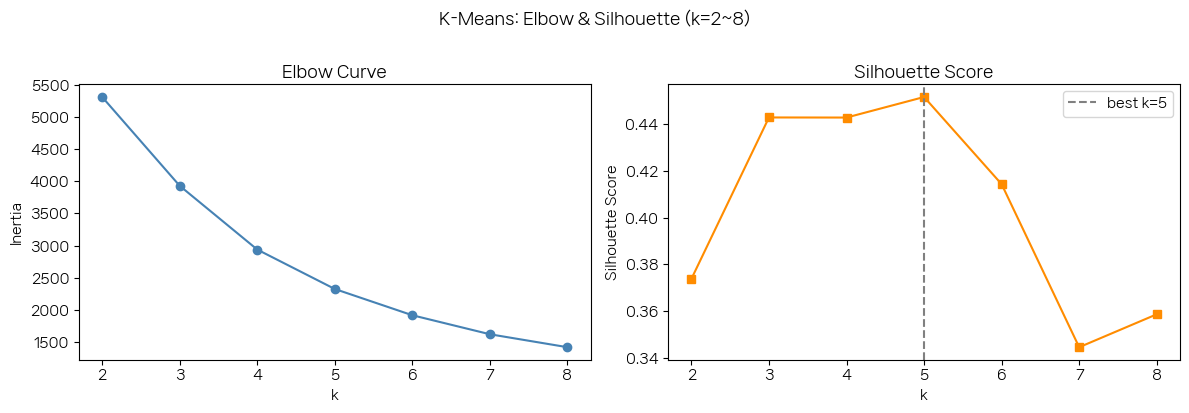

In [2]:
ks          = list(range(2, 9))
inertias    = []
silhouettes = []

for k in ks:
    km     = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

best_k   = ks[int(np.argmax(silhouettes))]
best_sil = max(silhouettes)
print(f'Best k = {best_k},  Silhouette = {best_sil:.4f}')
for k, sil in zip(ks, silhouettes):
    marker = ' <-- best' if k == best_k else ''
    print(f'  k={k}: {sil:.4f}{marker}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ks, inertias, 'o-', color='steelblue')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Curve'); ax1.set_xticks(ks)

ax2.plot(ks, silhouettes, 's-', color='darkorange')
ax2.axvline(best_k, linestyle='--', color='gray', label=f'best k={best_k}')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score'); ax2.set_xticks(ks); ax2.legend()

plt.suptitle('K-Means: Elbow & Silhouette (k=2~8)', y=1.02)
plt.tight_layout()
plt.savefig("figures/01_kmeans_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()


In [3]:
km_best = KMeans(n_clusters=best_k, n_init=20, random_state=42)
df_final.loc[idx, 'cluster_km'] = km_best.fit_predict(X)

# 파킹 클러스터 = delta_level 평균이 가장 낮은 클러스터
profile = df_final.loc[idx].groupby('cluster_km')[
    CLUSTER_FEATURES + ['stagnation_score']
].mean()

parking_cluster_id = int(profile['avg_monthly_delta_level'].idxmin())

profile['parked_proxy_%'] = (
    df_final.loc[idx].groupby('cluster_km')
    .apply(lambda g: (g['avg_monthly_delta_level'] <= 0.1).mean() * 100)
)
profile['n'] = df_final.loc[idx].groupby('cluster_km').size()
profile['is_parking'] = (profile.index == parking_cluster_id).astype(int)

print(f'최적 k = {best_k},  파킹 클러스터 ID = {parking_cluster_id}')
print()
display(profile.round(4))

# level_band 분포
print('\n레벨 밴드 분포 (클러스터 x level_band, 행 비율 %):')
lb_dist = pd.crosstab(
    df_final.loc[idx, 'cluster_km'],
    df_final.loc[idx, 'level_band'],
    normalize='index'
).round(3) * 100
display(lb_dist)


최적 k = 5,  파킹 클러스터 ID = 1



,avg_monthly_delta_level,delta_cp,delta_union,avg_monthly_delta_authentic_symbol,arcane_stagnant,stagnation_score,parked_proxy_%,n,is_parking
cluster_km,,,,,,,,,
0.0,0.3418,1.669930e+06,32.4793,0.7227,0.000,1.4236,25.7303,890,0
1.0,0.1062,-2.799087e+04,6.0694,0.0435,1.000,4.4615,78.8462,52,1
2.0,0.7048,1.449717e+07,55.4404,1.6959,0.000,0.0450,0.0000,400,0
3.0,10.5760,5.226256e+06,218.0848,0.7880,0.125,0.8750,0.0000,8,0
4.0,1.1877,5.354839e+06,444.4844,1.5696,0.000,0.5000,6.6667,30,0



레벨 밴드 분포 (클러스터 x level_band, 행 비율 %):


level_band,260s,270s,280s,290s,300
cluster_km,,,,,
0.0,6.5,17.5,34.8,41.1,0.0
1.0,71.2,26.9,1.9,0.0,0.0
2.0,0.0,0.2,18.8,79.2,1.8
3.0,0.0,37.5,62.5,0.0,0.0
4.0,3.3,10.0,73.3,13.3,0.0


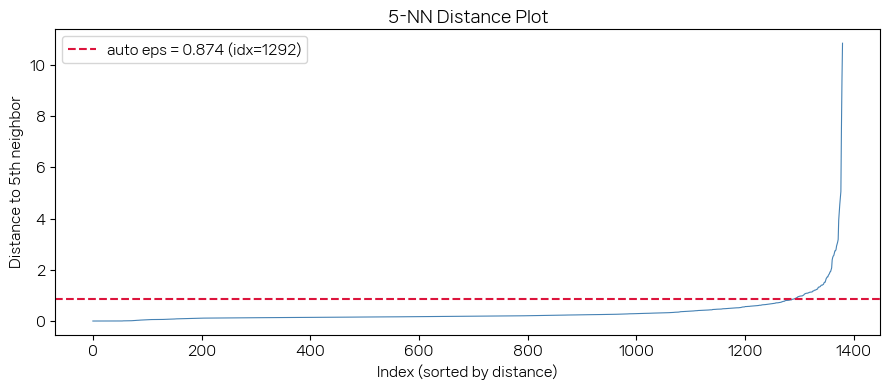

자동 eps = 0.8737

DBSCAN: 2개 클러스터,  noise = 6.7%
                       count
cluster_db (-1=noise)       
-1                        93
 0                      1236
 1                        51

K-Means x DBSCAN 교차표:


DBSCAN label,-1,0,1
KM (parking=1),,,
0,92,1236,0
1,1,0,51


In [4]:
# k-distance plot (k=5)
nbrs  = NearestNeighbors(n_neighbors=5).fit(X)
dists = np.sort(nbrs.kneighbors(X)[0][:, 4])

# 자동 eps: 정규화 후 대각선과의 거리 최대 지점 (knee/elbow)
y_norm = (dists - dists.min()) / (dists.max() - dists.min() + 1e-12)
x_norm = np.linspace(0, 1, len(y_norm))
elbow_idx = int(np.argmax(np.abs(y_norm - x_norm)))
eps_auto  = float(dists[elbow_idx])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(dists, color='steelblue', linewidth=0.8)
ax.axhline(eps_auto, linestyle='--', color='crimson',
           label=f'auto eps = {eps_auto:.3f} (idx={elbow_idx})')
ax.set_title('5-NN Distance Plot')
ax.set_xlabel('Index (sorted by distance)')
ax.set_ylabel('Distance to 5th neighbor')
ax.legend(); plt.tight_layout()
plt.savefig("figures/02_dbscan_kdist.png", dpi=150, bbox_inches="tight")
plt.show()
print(f'자동 eps = {eps_auto:.4f}')

# DBSCAN
db = DBSCAN(eps=eps_auto, min_samples=10).fit(X)
df_final.loc[idx, 'cluster_db'] = db.labels_

n_clusters_db = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
noise_ratio   = (db.labels_ == -1).mean()
print(f'\nDBSCAN: {n_clusters_db}개 클러스터,  noise = {noise_ratio:.1%}')
db_counts = pd.Series(db.labels_).value_counts().sort_index().rename('count')
db_counts.index.name = 'cluster_db (-1=noise)'
print(db_counts.to_frame().to_string())

# K-Means x DBSCAN 교차표
is_parking_km = (df_final.loc[idx, 'cluster_km'] == parking_cluster_id).astype(int)
ct = pd.crosstab(is_parking_km, db.labels_,
                 rownames=['KM (parking=1)'], colnames=['DBSCAN label'])
print('\nK-Means x DBSCAN 교차표:')
display(ct)


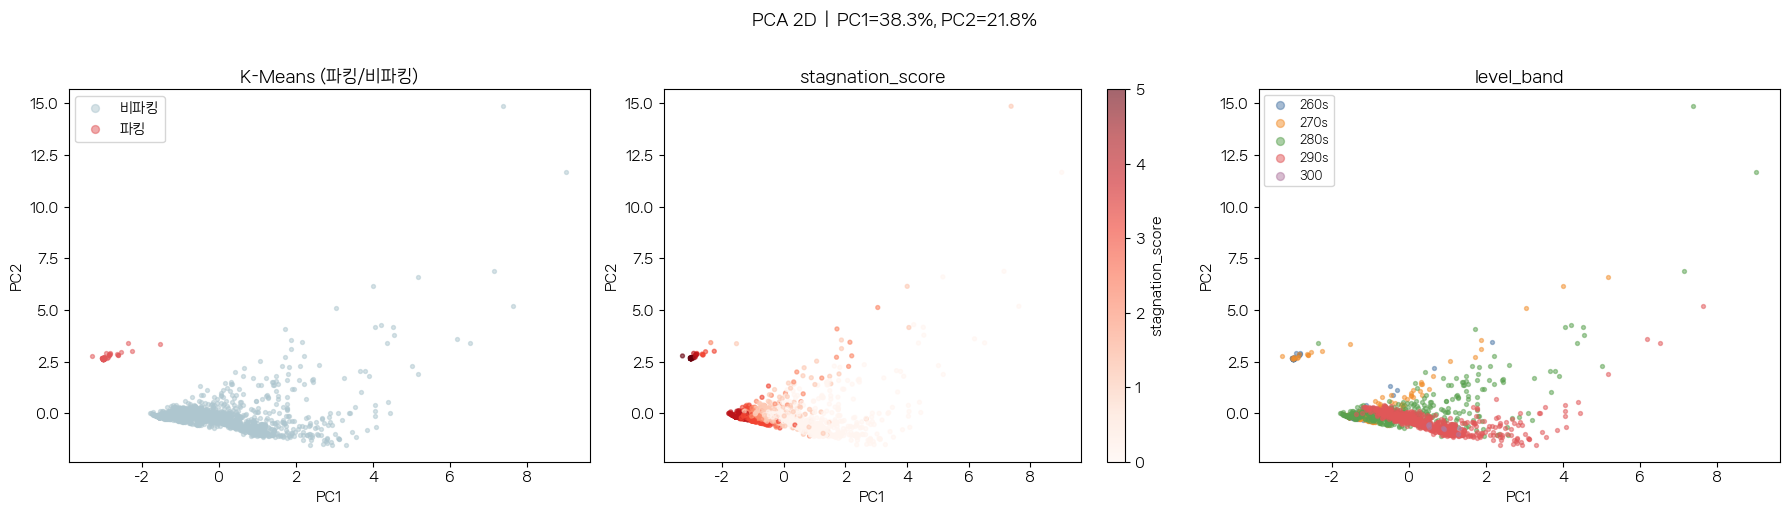

In [5]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=idx)
pca_df = pca_df.join(df_final[['cluster_km', 'stagnation_score', 'level_band']])
pca_df['is_parking'] = (pca_df['cluster_km'] == parking_cluster_id).astype(int)

BAND_PALETTE = {'260s': '#4e79a7', '270s': '#f28e2b', '280s': '#59a14f',
                '290s': '#e15759', '300': '#b07aa1'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: K-Means 파킹/비파킹
for cl, (color, lbl) in enumerate(zip(['#aec6cf', '#e15759'], ['비파킹', '파킹'])):
    mask = pca_df['is_parking'] == cl
    axes[0].scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
                    s=8, alpha=0.5, color=color, label=lbl)
axes[0].set_title('K-Means (파킹/비파킹)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=2)

# Panel 2: stagnation_score
sc = axes[1].scatter(pca_df['PC1'], pca_df['PC2'],
                     c=pca_df['stagnation_score'], cmap='Reds',
                     s=8, alpha=0.6, vmin=0, vmax=5)
plt.colorbar(sc, ax=axes[1], label='stagnation_score')
axes[1].set_title('stagnation_score')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

# Panel 3: level_band
for band in BAND_LABELS:
    mask = pca_df['level_band'].astype(str) == band
    if mask.sum() > 0:
        axes[2].scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
                        s=8, alpha=0.5,
                        color=BAND_PALETTE.get(band, 'gray'), label=band)
axes[2].set_title('level_band')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].legend(markerscale=2, fontsize=8)

ev = pca.explained_variance_ratio_
plt.suptitle(f'PCA 2D  |  PC1={ev[0]:.1%}, PC2={ev[1]:.1%}', y=1.02)
plt.tight_layout()
plt.savefig("figures/03_pca_3panel.png", dpi=150, bbox_inches="tight")
plt.show()


In [6]:
df_final['is_parking'] = (df_final['cluster_km'] == parking_cluster_id).astype(int)

# 클러스터 레이블 저장 (H2/H3에서 활용)
df_final[['cluster_km', 'is_parking']].to_csv(
    '../data/cluster_labels.csv', index=True, encoding='utf-8-sig'
)

h1_verdict = '분리 가능 (H1 지지)' if best_sil > 0.3 else '약한 분리 (H1 조건부 지지)'
n_parking   = int(df_final['is_parking'].sum())
n_stag5_all = int((df_final['stagnation_score'] == 5).sum())
n_stag5_in  = int(
    (df_final.loc[df_final['is_parking'] == 1, 'stagnation_score'] == 5).sum()
)

print('=' * 55)
print('  H1 판정')
print('=' * 55)
print(f'  Silhouette Score : {best_sil:.4f}')
print(f'  판정             : {h1_verdict}')
print(f'  파킹 클러스터    : {n_parking}명  ({n_parking / len(df_final):.1%})')
print(f'  stagnation=5 집중: {n_stag5_in}/{n_stag5_all}명'
      f'  ({n_stag5_in / max(n_stag5_all, 1) * 100:.1f}%)')
print()
print('  data/cluster_labels.csv 저장 완료')
print('  다음: H2 분포 검정 (Chi-Square by level_band & class_group)')


  H1 판정
  Silhouette Score : 0.4517
  판정             : 분리 가능 (H1 지지)
  파킹 클러스터    : 52명  (3.8%)
  stagnation=5 집중: 36/36명  (100.0%)

  data/cluster_labels.csv 저장 완료
  다음: H2 분포 검정 (Chi-Square by level_band & class_group)
